
🚀 INITIALIZING LUGRE PINN FOR JOINT 1 | FILE: 1_Unique.csv
Training started for Joint 1. Data points: 5396...
   Epoch 0300 | Total Loss: 17679326.000000 | Data Loss (MSE): 416.292084
   Epoch 0600 | Total Loss: 3327514.500000 | Data Loss (MSE): 111.420906
   Epoch 0900 | Total Loss: 3878913.000000 | Data Loss (MSE): 88.172256
   Epoch 1200 | Total Loss: 3231263.250000 | Data Loss (MSE): 76.931526
   Epoch 1500 | Total Loss: 2917714.500000 | Data Loss (MSE): 62.904678

----------------------------------------
🏆 JOINT 1 RESULTS
----------------------------------------
Sigma_0 (Stiffness) = 100.0001
Sigma_1 (Damping) = 1.0001
Sigma_2 (Viscous) = 0.1001
Fc (Coulomb) = 0.5001
Fs (Static) = 1.0001
Vs (Stribeck Vel) = 0.1001
Test R² = -65.2481
Test RMSE = 9.4496


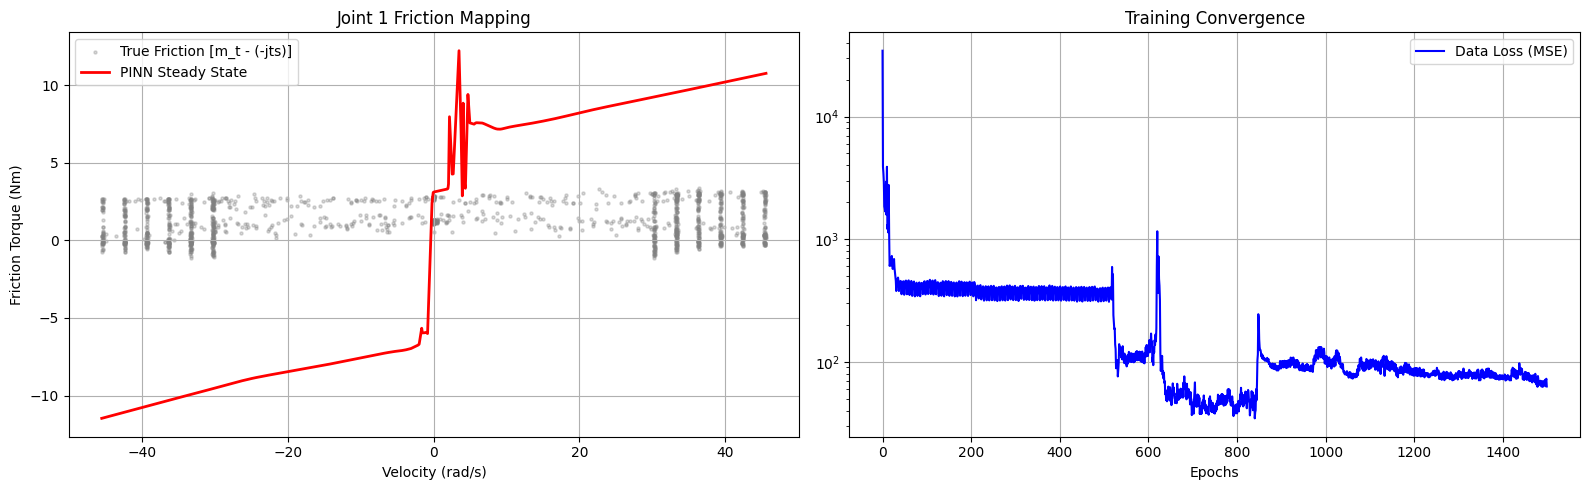


🚀 INITIALIZING LUGRE PINN FOR JOINT 2 | FILE: 2_Unique.csv
Training started for Joint 2. Data points: 469...
   Epoch 0300 | Total Loss: 8196464.500000 | Data Loss (MSE): 4666.926758
   Epoch 0600 | Total Loss: 1496388.750000 | Data Loss (MSE): 4020.408447
   Epoch 0900 | Total Loss: 724552.000000 | Data Loss (MSE): 3971.106934
   Epoch 1200 | Total Loss: 1033707.625000 | Data Loss (MSE): 3972.799316
   Epoch 1500 | Total Loss: 3091235.000000 | Data Loss (MSE): 3984.785645

----------------------------------------
🏆 JOINT 2 RESULTS
----------------------------------------
Sigma_0 (Stiffness) = 100.0001
Sigma_1 (Damping) = 1.0001
Sigma_2 (Viscous) = 0.1001
Fc (Coulomb) = 0.5001
Fs (Static) = 1.0001
Vs (Stribeck Vel) = 0.1001
Test R² = 0.0332
Test RMSE = 69.4766


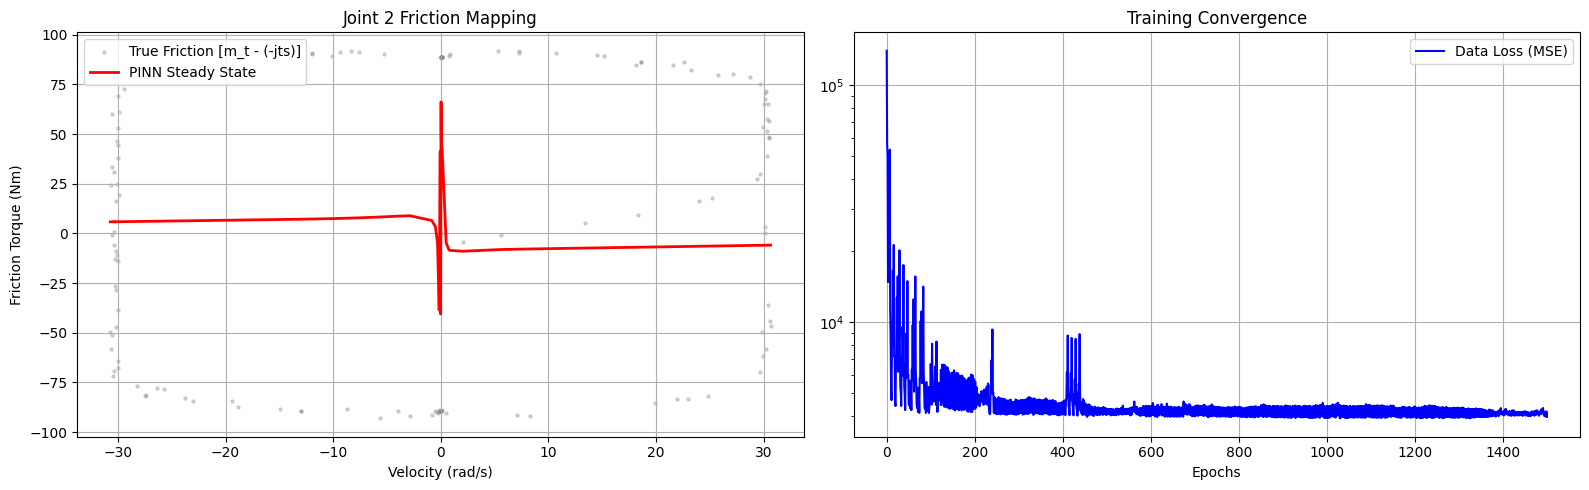


🚀 INITIALIZING LUGRE PINN FOR JOINT 3 | FILE: 3_Unique.csv
Training started for Joint 3. Data points: 1337...
   Epoch 0300 | Total Loss: 11760356.000000 | Data Loss (MSE): 1256.341675
   Epoch 0600 | Total Loss: 7910858.500000 | Data Loss (MSE): 1257.687866
   Epoch 0900 | Total Loss: 1922642.500000 | Data Loss (MSE): 1039.054688
   Epoch 1200 | Total Loss: 2104829.750000 | Data Loss (MSE): 1020.506775
   Epoch 1500 | Total Loss: 1754675.500000 | Data Loss (MSE): 1055.174438

----------------------------------------
🏆 JOINT 3 RESULTS
----------------------------------------
Sigma_0 (Stiffness) = 100.0001
Sigma_1 (Damping) = 1.0001
Sigma_2 (Viscous) = 0.1001
Fc (Coulomb) = 0.5001
Fs (Static) = 1.0001
Vs (Stribeck Vel) = 0.1001
Test R² = -0.0037
Test RMSE = 30.8232


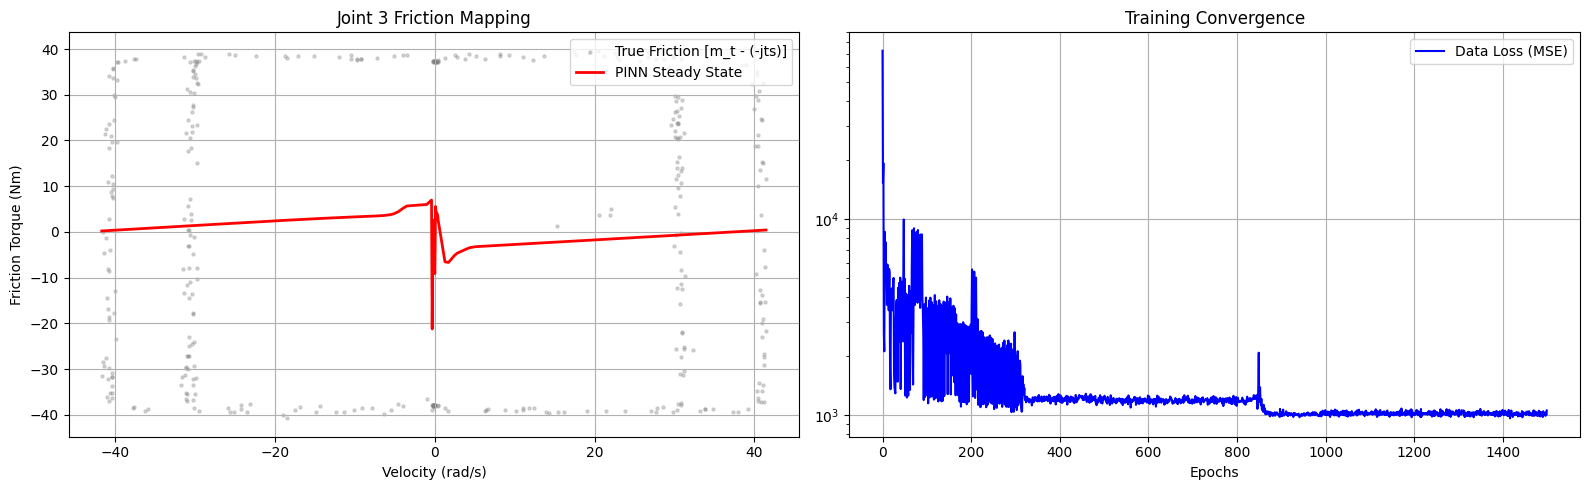


🚀 INITIALIZING LUGRE PINN FOR JOINT 5 | FILE: 5_Unique.csv
Training started for Joint 5. Data points: 3662...
   Epoch 0300 | Total Loss: 4148266.750000 | Data Loss (MSE): 157.548965
   Epoch 0600 | Total Loss: 5317620.500000 | Data Loss (MSE): 208.462448
   Epoch 0900 | Total Loss: 3422671.000000 | Data Loss (MSE): 130.347809
   Epoch 1200 | Total Loss: 3049318.750000 | Data Loss (MSE): 109.241859
   Epoch 1500 | Total Loss: 3109894.500000 | Data Loss (MSE): 98.478523

----------------------------------------
🏆 JOINT 5 RESULTS
----------------------------------------
Sigma_0 (Stiffness) = 100.0001
Sigma_1 (Damping) = 1.0001
Sigma_2 (Viscous) = 0.1001
Fc (Coulomb) = 0.5001
Fs (Static) = 1.0001
Vs (Stribeck Vel) = 0.1001
Test R² = -3.6706
Test RMSE = 8.6340


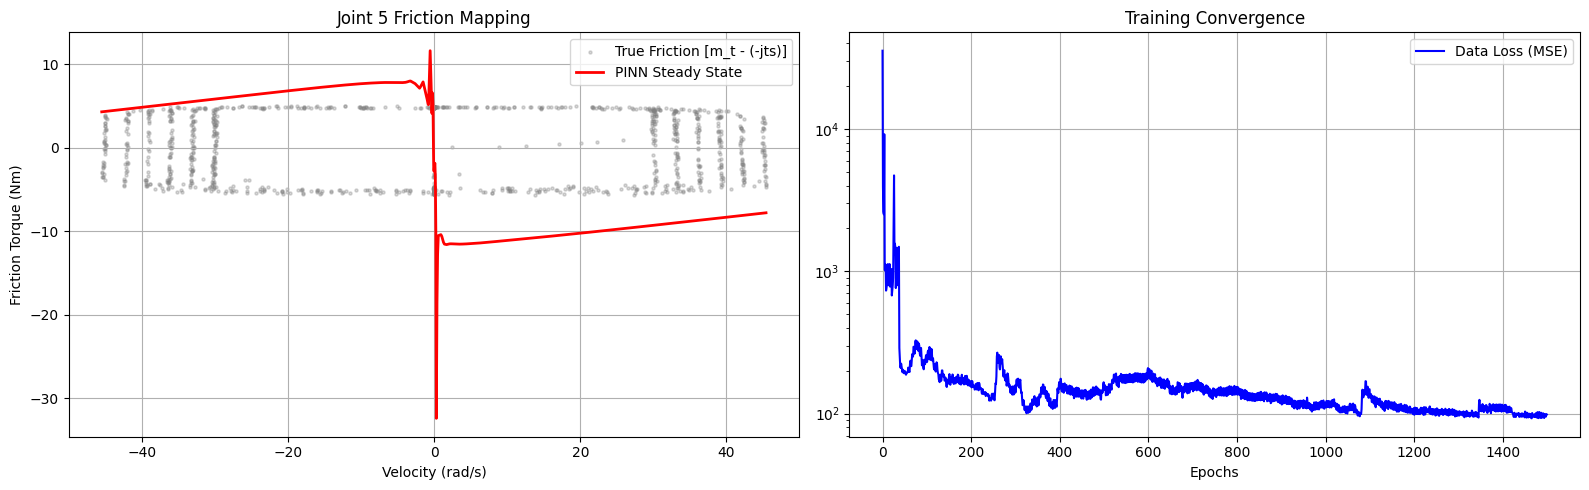


📊 GENERATING CORRELATION MATRICES


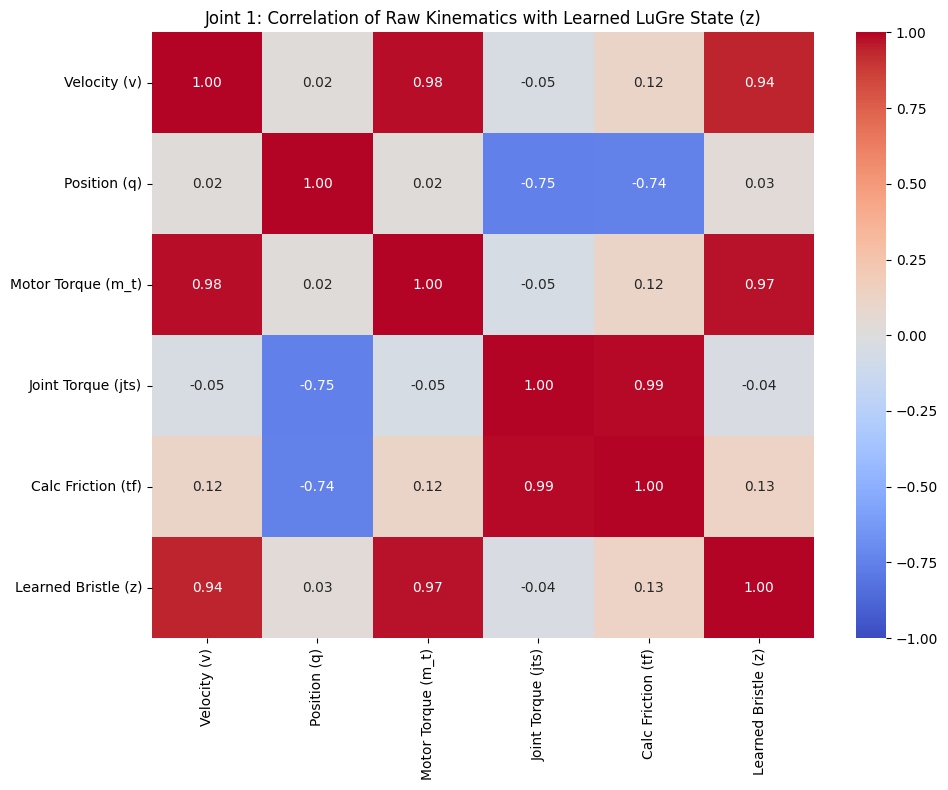

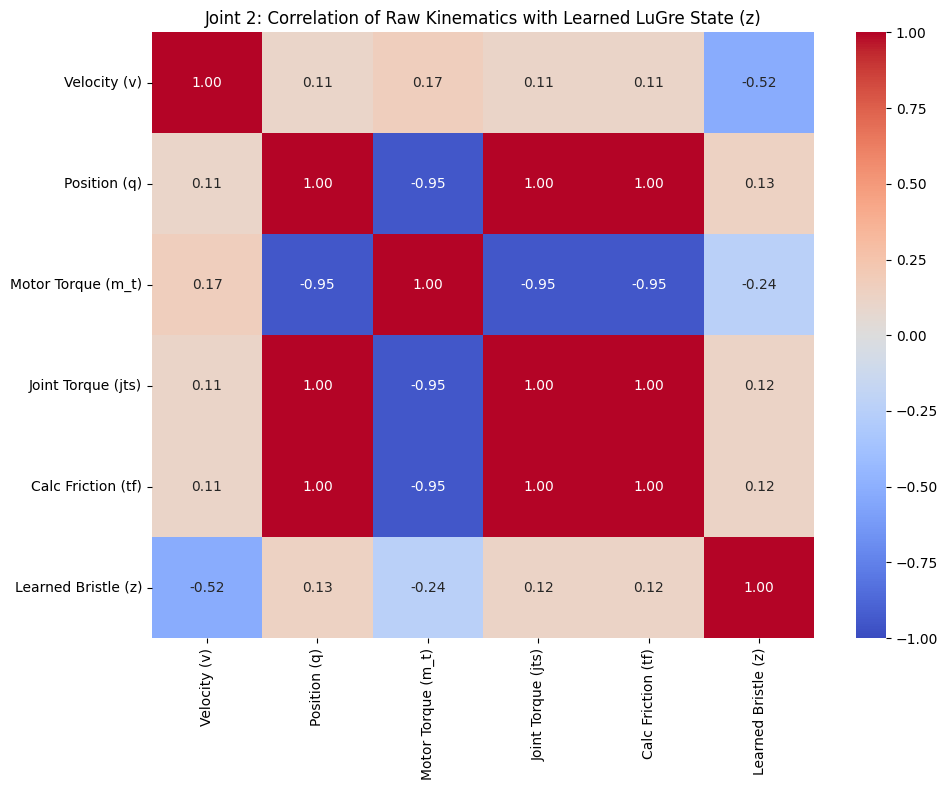

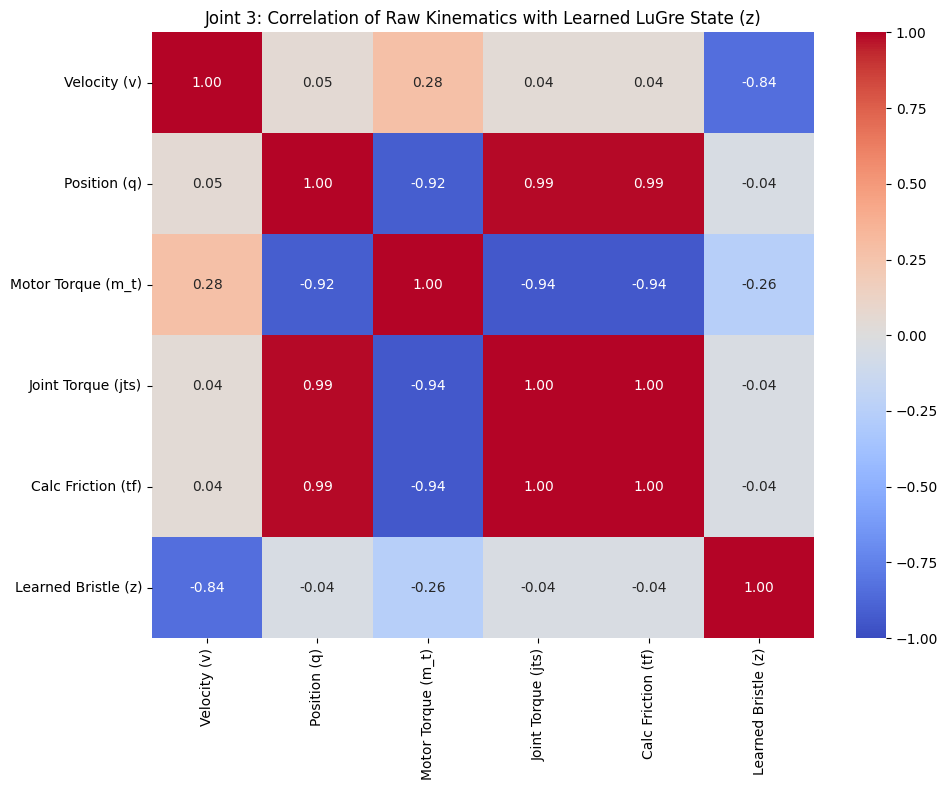

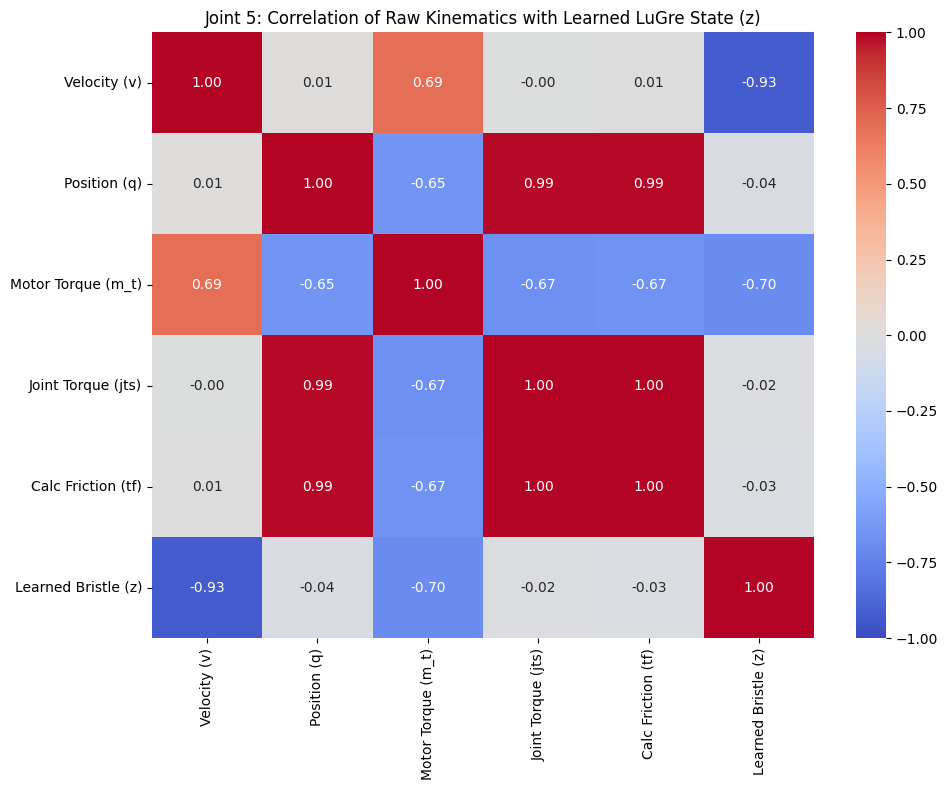


🎯 ALL JOINTS TRAINING COMPLETE - SUMMARY
Joint 1 | R²: -65.2481 | RMSE: 9.4496 | Fc: 0.5001 | Fs: 1.0001
Joint 2 | R²: 0.0332 | RMSE: 69.4766 | Fc: 0.5001 | Fs: 1.0001
Joint 3 | R²: -0.0037 | RMSE: 30.8232 | Fc: 0.5001 | Fs: 1.0001
Joint 5 | R²: -3.6706 | RMSE: 8.6340 | Fc: 0.5001 | Fs: 1.0001


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Ensure float32 globally for consistent gradients
tf.keras.backend.set_floatx('float32')

# ---------------------------------------------------------
# 1. PURE LUGRE ARCHITECTURE (Paper Approach)
# ---------------------------------------------------------
class LuGrePINN(tf.keras.Model):
    def __init__(self):
        super(LuGrePINN, self).__init__()
        
        # Smooth activation functions for valid 2nd-order gradients
        self.d1 = tf.keras.layers.Dense(128, activation='tanh')
        self.d2 = tf.keras.layers.Dense(128, activation='tanh')
        self.d3 = tf.keras.layers.Dense(128, activation='tanh')
        self.d4 = tf.keras.layers.Dense(128, activation='tanh')
        self.z_out = tf.keras.layers.Dense(1, activation='linear')
        
        # LuGre Physics Parameters 
        # Initialized slightly higher to prevent early optimizer freezing
        self.sigma_0_var = tf.Variable(100.0, trainable=True, dtype=tf.float32)
        self.sigma_1_var = tf.Variable(1.0, trainable=True, dtype=tf.float32)
        self.sigma_2_var = tf.Variable(0.1, trainable=True, dtype=tf.float32)
        self.fc_var = tf.Variable(0.5, trainable=True, dtype=tf.float32)
        self.fs_var = tf.Variable(1.0, trainable=True, dtype=tf.float32)
        self.vs_var = tf.Variable(0.1, trainable=True, dtype=tf.float32)

    def call(self, v):
        x = self.d1(v)
        x = self.d2(x)
        x = self.d3(x)
        x = self.d4(x)
        return self.z_out(x)

    def get_physics_params(self):
        # Enforce physical constraints: friction parameters must be strictly positive
        s0 = tf.math.abs(self.sigma_0_var) + 1e-4
        s1 = tf.math.abs(self.sigma_1_var) + 1e-4
        s2 = tf.math.abs(self.sigma_2_var) + 1e-4
        fc = tf.math.abs(self.fc_var) + 1e-4
        fs = tf.math.abs(self.fs_var) + 1e-4
        vs = tf.math.abs(self.vs_var) + 1e-4
        
        # Static friction must be strictly greater than Coulomb friction physically
        fs = tf.maximum(fs, fc + 1e-4) 
        
        return s0, s1, s2, fc, fs, vs

# ---------------------------------------------------------
# 2. DATA LOAD AND MAIN LOOP
# ---------------------------------------------------------
# Set the folder path to where your unique CSV files are located
folder_path = r"S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data/12_06_2026"
all_files = {
    1: "1_Unique.csv",
    2: "2_Unique.csv",
    3: "3_Unique.csv",
    5: "5_Unique.csv"
}

epochs = 1500
batch_size = 256
lambda_phy = 10.0 # Lowered scaling so Data Loss can guide the parameters initially

results_summary = {}
correlation_data = {} 

for joint, filename in all_files.items():
    print("\n" + "="*80)
    print(f"🚀 INITIALIZING LUGRE PINN FOR JOINT {joint} | FILE: {filename}")
    print("="*80)
    
    file_path = os.path.join(folder_path, filename)
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"File {filename} not found. Ensure it is in the correct directory.")
        continue
        
    # Extract Columns
    v = df[f'v{joint}'].values
    q = df[f'q{joint}'].values
    m_t = df[f'm_t_{joint}'].values
    jts = df[f'jts{joint}'].values
    
    # ---------------------------------------------------------
    # CALCULATE TRUE FRICTION (Your exact hardware equation)
    # tf = mt - (-tj)  => tf = mt + tj
    # ---------------------------------------------------------
    f_meas = m_t + jts
    
    # CRITICAL FIX: Ensure friction structurally opposes velocity.
    # If the hardware sign convention makes f_meas the opposite sign of velocity,
    # the optimizer will freeze because physical parameters (Fc, Fs) cannot be negative.
    align_mask = np.sign(f_meas) != np.sign(v)
    if np.mean(align_mask) > 0.5:
        print("   [WARNING] Hardware convention inverted. Aligning friction signs for LuGre physics...")
        f_meas = -f_meas
    
    # ZERO ACCELERATION (Steady-State Data assumption)
    a = np.zeros_like(v)
    
    v_tf = v.reshape(-1, 1).astype(np.float32)
    a_tf = a.reshape(-1, 1).astype(np.float32)
    f_tf = f_meas.reshape(-1, 1).astype(np.float32)
    
    # Train/Val/Test Split
    v_train_val, v_test, a_train_val, a_test, f_train_val, f_test = train_test_split(
        v_tf, a_tf, f_tf, test_size=0.2, random_state=42)
    v_train, v_val, a_train, a_val, f_train, f_val = train_test_split(
        v_train_val, a_train_val, f_train_val, test_size=0.125, random_state=42)
    
    train_dataset = tf.data.Dataset.from_tensor_slices((v_train, a_train, f_train)).shuffle(10000).batch(batch_size)
    
    model = LuGrePINN()
    # Boosted learning rate to help parameters unfreeze and escape initial guesses
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.005)
    
    @tf.function
    def train_step(v_batch, a_batch, f_batch):
        with tf.GradientTape() as outer_tape:
            with tf.GradientTape() as inner_tape:
                inner_tape.watch(v_batch)
                z = model(v_batch)
                
            dz_dv = inner_tape.gradient(z, v_batch)
            
            # Since a_batch is 0, z_dot_model becomes 0 (perfect steady-state physics)
            z_dot_model = dz_dv * a_batch 
            
            s0, s1, s2, fc, fs, vs = model.get_physics_params()
            
            # Exact LuGre Equations from the paper
            g_v = fc + (fs - fc) * tf.exp(-tf.square(tf.abs(v_batch) / vs))
            z_dot_lugre = v_batch - ((s0 * tf.abs(v_batch)) / g_v) * z
            f_pred = (s0 * z) + (s1 * z_dot_model) + (s2 * v_batch)
            
            loss_data = tf.reduce_mean(tf.square(f_batch - f_pred))
            loss_phy = tf.reduce_mean(tf.square(z_dot_model - z_dot_lugre))
            
            total_loss = loss_data + lambda_phy * loss_phy

        gradients = outer_tape.gradient(total_loss, model.trainable_variables)
        
        # Gradient clipping prevents the optimizer from blowing up on the exponential terms
        clipped_gradients = [tf.clip_by_value(g, -1.0, 1.0) if g is not None else g for g in gradients]
        optimizer.apply_gradients(zip(clipped_gradients, model.trainable_variables))
        
        return total_loss, loss_data, loss_phy

    # ---------------------------------------------------------
    # 3. TRAINING LOOP
    # ---------------------------------------------------------
    print(f"Training started for Joint {joint}. Data points: {len(v_train)}...")
    history = {'loss': [], 'data_loss': [], 'phy_loss': []}
    
    for epoch in range(epochs):
        epoch_loss_total, epoch_loss_data, epoch_loss_phy, steps = 0, 0, 0, 0
        for v_b, a_b, f_b in train_dataset:
            lt, ld, lp = train_step(v_b, a_b, f_b)
            epoch_loss_total += lt.numpy()
            epoch_loss_data += ld.numpy()
            epoch_loss_phy += lp.numpy()
            steps += 1
            
        history['loss'].append(epoch_loss_total / steps)
        history['data_loss'].append(epoch_loss_data / steps)
        history['phy_loss'].append(epoch_loss_phy / steps)
        
        if (epoch + 1) % 300 == 0:
            print(f"   Epoch {epoch+1:04d} | Total Loss: {history['loss'][-1]:.6f} | Data Loss (MSE): {history['data_loss'][-1]:.6f}")

    # ---------------------------------------------------------
    # 4. EVALUATION
    # ---------------------------------------------------------
    s0, s1, s2, fc, fs, vs = [p.numpy() for p in model.get_physics_params()]
    
    v_test_tf = tf.convert_to_tensor(v_test)
    a_test_tf = tf.convert_to_tensor(a_test)
    
    with tf.GradientTape() as tape:
        tape.watch(v_test_tf)
        z_pred = model(v_test_tf)
    dz_dv_test = tape.gradient(z_pred, v_test_tf)
    z_dot_pred = dz_dv_test * a_test_tf
    
    f_test_pred = ((s0 * z_pred) + (s1 * z_dot_pred) + (s2 * v_test_tf)).numpy()
    
    rmse = np.sqrt(mean_squared_error(f_test, f_test_pred))
    r2 = r2_score(f_test, f_test_pred)
    
    results_summary[joint] = {'R2': r2, 'RMSE': rmse, 'Fc': fc, 'Fs': fs}
    
    # Store full data arrays for the correlation matrix
    correlation_data[joint] = {
        'Velocity (v)': v,
        'Position (q)': q,
        'Motor Torque (m_t)': m_t,
        'Joint Torque (jts)': jts,
        'Calc Friction (tf)': f_meas,
        'Learned Bristle (z)': model(tf.convert_to_tensor(v.reshape(-1, 1).astype(np.float32))).numpy().ravel()
    }

    print("\n" + "-"*40)
    print(f"🏆 JOINT {joint} RESULTS")
    print("-"*40)
    print(f"Sigma_0 (Stiffness) = {s0:.4f}")
    print(f"Sigma_1 (Damping) = {s1:.4f}")
    print(f"Sigma_2 (Viscous) = {s2:.4f}")
    print(f"Fc (Coulomb) = {fc:.4f}")
    print(f"Fs (Static) = {fs:.4f}")
    print(f"Vs (Stribeck Vel) = {vs:.4f}")
    print(f"Test R² = {r2:.4f}")
    print(f"Test RMSE = {rmse:.4f}")
    
    # ---------------------------------------------------------
    # PLOTS FOR JOINT
    # ---------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    idx = np.argsort(v_test.ravel())
    ax1.scatter(v_test.ravel(), f_test.ravel(), s=5, alpha=0.3, label="True Friction [m_t - (-jts)]", color='gray')
    ax1.plot(v_test.ravel()[idx], f_test_pred.ravel()[idx], color='red', linewidth=2, label="PINN Steady State")
    ax1.set_xlabel("Velocity (rad/s)")
    ax1.set_ylabel("Friction Torque (Nm)")
    ax1.set_title(f"Joint {joint} Friction Mapping")
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(history['data_loss'], label="Data Loss (MSE)", color='blue')
    ax2.set_yscale('log')
    ax2.set_xlabel("Epochs")
    ax2.set_title("Training Convergence")
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 5. KINEMATIC & STATE CORRELATION MATRIX
# ---------------------------------------------------------
print("\n" + "="*80)
print("📊 GENERATING CORRELATION MATRICES")
print("="*80)

for joint, data in correlation_data.items():
    df_corr = pd.DataFrame(data)
    corr_matrix = df_corr.corr()
    
    plt.figure(figsize=(10, 8))
    # Plot a beautiful heatmap showing how raw measurements relate to the unmeasured state 'z'
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
    plt.title(f"Joint {joint}: Correlation of Raw Kinematics with Learned LuGre State (z)")
    plt.tight_layout()
    plt.show()

# Final Run Summary
print("\n" + "="*80)
print("🎯 ALL JOINTS TRAINING COMPLETE - SUMMARY")
print("="*80)
for j, res in results_summary.items():
    print(f"Joint {j} | R²: {res['R2']:.4f} | RMSE: {res['RMSE']:.4f} | Fc: {res['Fc']:.4f} | Fs: {res['Fs']:.4f}")